# 01 — Environment and Tabular Baselines

This notebook establishes the first experimental foundation for the Mountain Car project.

Our goal here is not yet to test every reinforcement learning algorithm in the assignment, but to build a clean and understandable starting point. We begin by inspecting the environment, understanding its state and action spaces, and explaining why classical tabular methods cannot directly operate on the raw Mountain Car state.

In the standard discrete version of the environment, the state contains two continuous values:

- **position**
- **velocity**

The action space is discrete, with three possible actions:

- push left
- apply no push
- push right

This combination is important. Even though the action space is discrete, the state space is still continuous. That means a classical Q-table cannot directly assign a separate entry to every exact state value. This is why we will later need discretization.

- **Q-learning**
- **SARSA**

These methods are useful starting points because they are simple, interpretable, and let us study key RL ideas such as value estimation, exploration, convergence behavior, and policy learning before moving to deeper methods such as DQN and DDQN.

## Q-Learning Baseline
We begin with Q-learning as the first baseline for the discrete-action version of Mountain Car. Q-learning is a tabular value-based reinforcement learning method that estimates how good each action is in each state. Since the Mountain Car state is continuous, we cannot directly store one Q-value per exact state, so we discretize the state space into bins over position and velocity. This gives us an approximate Q-table over a finite grid. The purpose of this first baseline is not yet to optimize performance fully, but to establish a working training and evaluation pipeline that later methods can be compared against. The assignment explicitly emphasizes representation design, hyperparameters, evaluation, and policy analysis, so this baseline serves as the reference point for the rest of the project.

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt 
from collections import defaultdict

In [2]:
env = gym.make("MountainCar-v0")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, info = env.reset(seed=42)
print("Initial state:", state)
print("Position range:", env.observation_space.low[0], "to", env.observation_space.high[0])
print("Velocity range:", env.observation_space.low[1], "to", env.observation_space.high[1])
print("Number of actions:", env.action_space.n)

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Initial state: [-0.4452088  0.       ]
Position range: -1.2 to 0.6
Velocity range: -0.07 to 0.07
Number of actions: 3


We convert continuous (position, velocity) into grid indices

In [3]:
# number of bins for each state dimension
N_POS_BINS = 20
N_VEL_BINS = 20

pos_low, vel_low = env.observation_space.low
pos_high, vel_high = env.observation_space.high

pos_bins = np.linspace(pos_low, pos_high, N_POS_BINS + 1)
vel_bins = np.linspace(vel_low, vel_high, N_VEL_BINS + 1)

def discretize_state(state):
    position, velocity = state

    pos_idx = np.digitize(position, pos_bins) - 1
    vel_idx = np.digitize(velocity, vel_bins) - 1

    # keep indices inside valid range
    pos_idx = np.clip(pos_idx, 0, N_POS_BINS - 1)
    vel_idx = np.clip(vel_idx, 0, N_VEL_BINS - 1)

    return (pos_idx, vel_idx)

# quick test
test_state, _ = env.reset(seed=42)
print("Raw state:", test_state)
print("Discretized state:", discretize_state(test_state))

Raw state: [-0.4452088  0.       ]
Discretized state: (np.int64(8), np.int64(10))


Intialize Q-table

In [4]:
n_actions = env.action_space.n
Q = np.zeros((N_POS_BINS, N_VEL_BINS, n_actions))

print("Q-table shape:", Q.shape)

Q-table shape: (20, 20, 3)


Epsilon-greedy

In [5]:
def choose_action(state_disc, Q, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state_disc])

Q-learning train loop

In [6]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05
):
    rewards_per_episode = []
    steps_per_episode = []
    success_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        state_disc = discretize_state(state)

        done = False
        total_reward = 0
        steps = 0
        success = 0

        while not done:
            action = choose_action(state_disc, Q, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state_disc = discretize_state(next_state)

            done = terminated or truncated

            # Q-learning update
            best_next_q = np.max(Q[next_state_disc])
            td_target = reward + gamma * best_next_q * (not done)
            td_error = td_target - Q[state_disc + (action,)]
            Q[state_disc + (action,)] += alpha * td_error

            state_disc = next_state_disc
            total_reward += reward
            steps += 1

            if terminated:
                success = 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        success_per_episode.append(success)

        if (episode + 1) % 500 == 0:
            avg_reward = np.mean(rewards_per_episode[-500:])
            avg_success = np.mean(success_per_episode[-500:])
            print(
                f"Episode {episode+1}/{episodes} | "
                f"avg reward (last 500): {avg_reward:.2f} | "
                f"success rate (last 500): {avg_success:.3f} | "
                f"epsilon: {epsilon:.3f}"
            )

    return Q, rewards_per_episode, steps_per_episode, success_per_episode

In [7]:
Q = np.zeros((N_POS_BINS, N_VEL_BINS, n_actions))

Q, rewards, steps, successes = train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05
)

Episode 500/5000 | avg reward (last 500): -200.00 | success rate (last 500): 0.000 | epsilon: 0.606
Episode 1000/5000 | avg reward (last 500): -200.00 | success rate (last 500): 0.000 | epsilon: 0.368
Episode 1500/5000 | avg reward (last 500): -199.35 | success rate (last 500): 0.048 | epsilon: 0.223
Episode 2000/5000 | avg reward (last 500): -194.08 | success rate (last 500): 0.222 | epsilon: 0.135
Episode 2500/5000 | avg reward (last 500): -188.70 | success rate (last 500): 0.460 | epsilon: 0.082
Episode 3000/5000 | avg reward (last 500): -183.15 | success rate (last 500): 0.564 | epsilon: 0.050
Episode 3500/5000 | avg reward (last 500): -186.11 | success rate (last 500): 0.496 | epsilon: 0.050
Episode 4000/5000 | avg reward (last 500): -177.39 | success rate (last 500): 0.666 | epsilon: 0.050
Episode 4500/5000 | avg reward (last 500): -179.81 | success rate (last 500): 0.538 | epsilon: 0.050
Episode 5000/5000 | avg reward (last 500): -173.86 | success rate (last 500): 0.804 | epsilo

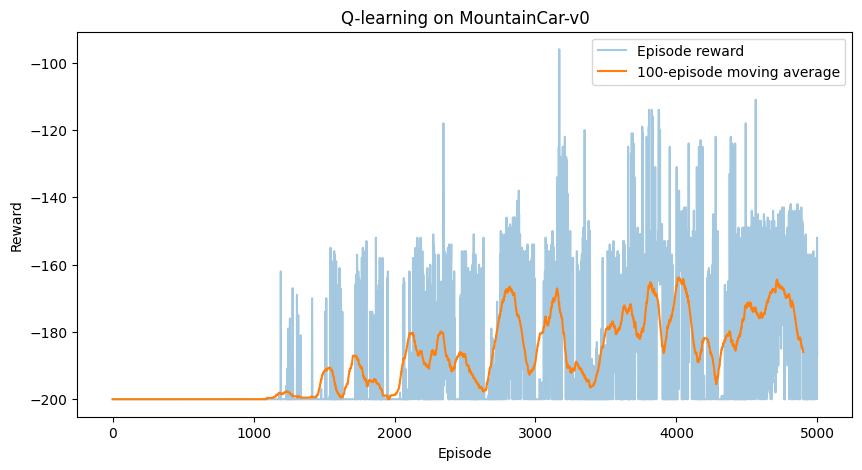

In [8]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.4, label="Episode reward")
plt.plot(moving_average(rewards, 100), label="100-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-learning on MountainCar-v0")
plt.legend()
plt.show()

Evaluate greedy performance

In [9]:
def evaluate_agent(env, Q, n_eval_episodes=100):
    rewards = []
    steps_list = []
    successes = []

    for _ in range(n_eval_episodes):
        state, _ = env.reset()
        state_disc = discretize_state(state)

        done = False
        total_reward = 0
        steps = 0
        success = 0

        while not done:
            action = np.argmax(Q[state_disc])  # greedy policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            state_disc = discretize_state(next_state)

            done = terminated or truncated
            total_reward += reward
            steps += 1

            if terminated:
                success = 1

        rewards.append(total_reward)
        steps_list.append(steps)
        successes.append(success)

    print("Evaluation over", n_eval_episodes, "episodes")
    print("Average reward:", np.mean(rewards))
    print("Average steps:", np.mean(steps_list))
    print("Success rate:", np.mean(successes))

    return rewards, steps_list, successes

eval_rewards, eval_steps, eval_successes = evaluate_agent(env, Q, n_eval_episodes=100)

Evaluation over 100 episodes
Average reward: -178.78
Average steps: 178.78
Success rate: 1.0


Visualize the learned policy

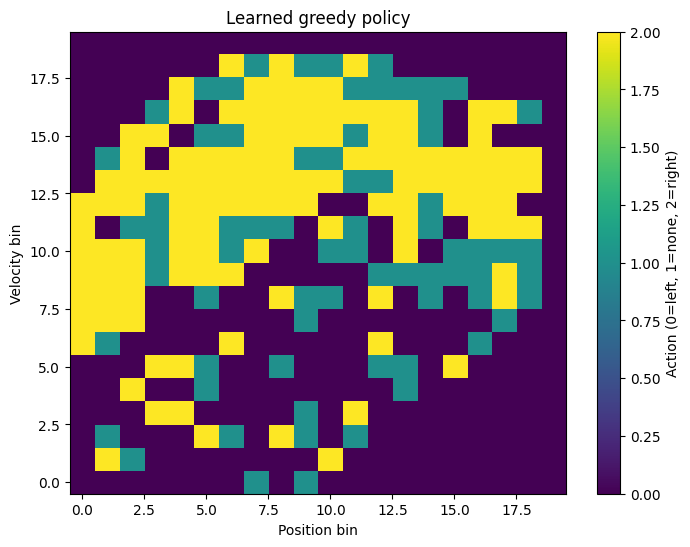

In [10]:
policy_map = np.argmax(Q, axis=2)

plt.figure(figsize=(8, 6))
plt.imshow(policy_map.T, origin="lower", aspect="auto")
plt.colorbar(label="Action (0=left, 1=none, 2=right)")
plt.xlabel("Position bin")
plt.ylabel("Velocity bin")
plt.title("Learned greedy policy")
plt.show()